In [ ]:
# Library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wheat_df = pd.read_csv('cleaned_wheat_yield_data.csv')

In [3]:
wheat_df.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,2,4,Afghanistan,15,111,Wheat,5412,Yield,kg/ha,1022.0,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
1,3,8,Albania,15,111,Wheat,5412,Yield,kg/ha,773.1,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
2,4,12,Algeria,15,111,Wheat,5412,Yield,kg/ha,406.0,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
3,7,24,Angola,15,111,Wheat,5412,Yield,kg/ha,1111.1,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
4,9,32,Argentina,15,111,Wheat,5412,Yield,kg/ha,1295.0,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6


In [4]:
wheat_df_slim = wheat_df[(wheat_df ['Item'] == 'Wheat') & (wheat_df ['Element'] == 'Yield')]
wheat_df_slim.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,2,4,Afghanistan,15,111,Wheat,5412,Yield,kg/ha,1022.0,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
1,3,8,Albania,15,111,Wheat,5412,Yield,kg/ha,773.1,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
2,4,12,Algeria,15,111,Wheat,5412,Yield,kg/ha,406.0,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
3,7,24,Angola,15,111,Wheat,5412,Yield,kg/ha,1111.1,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
4,9,32,Argentina,15,111,Wheat,5412,Yield,kg/ha,1295.0,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6


In [6]:
wheat_df_slim.set_index('Area', inplace=True)

In [8]:
year_cols = [col for col in wheat_df.columns if col.startswith('Y')]
df_numeric = wheat_df_slim[year_cols]

In [9]:
df_numeric.head()

,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,Y1969,Y1970,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
Area,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1022.0,973.5,831.7,951.0,972.3,866.6,1123.2,1156.2,1185.5,956.3,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
Albania,773.1,1052.2,712.7,962.5,1134.4,1239.8,1355.0,1412.4,1638.9,1537.7,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
Algeria,406.0,804.5,832.6,531.7,605.7,425.2,633.3,689.9,603.4,624.5,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
Angola,1111.1,1111.1,1111.1,928.6,1111.1,1100.0,1350.0,1350.0,943.0,854.6,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
Argentina,1295.0,1522.2,1575.1,1835.3,1321.2,1198.2,1259.5,983.3,1352.3,1329.4,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6


In [22]:
df_numeric.shape

(164, 63)

In [ ]:
# Ignore this cell, used to find N/A values
df_clean = df_numeric.dropna(axis=0, how='any')

In [ ]:
# Ignore this cell, used to find N/A values
df_clean.shape

(111, 63)

In [23]:
selection = [
    'Europe',
    'Least Developed Countries',
    'World',
    'Asia',
    'Africa',
    'North America',
    'South America',
    'Oceania'
]

In [26]:
df_manual_selection = df_clean.loc[df_clean.index.isin(selection)]

In [27]:
df_transposed = df_manual_selection.transpose()

In [28]:
df_transposed.head()

Area,World,Africa,South America,Asia,Europe,Oceania,Least Developed Countries
Y1961,1088.9,693.0,1135.8,748.6,1256.2,1156.9,935.1
Y1962,1206.0,923.6,1345.3,844.8,1326.9,1270.9,907.4
Y1963,1132.0,899.0,1379.1,853.2,1099.7,1357.5,815.0
Y1964,1241.3,873.6,1636.1,843.1,1351.8,1405.9,891.1
Y1965,1215.1,828.7,1244.6,975.5,1246.9,1021.6,901.3


In [29]:
df_transposed.index = df_transposed.index.str.replace('Y', '').astype(int)

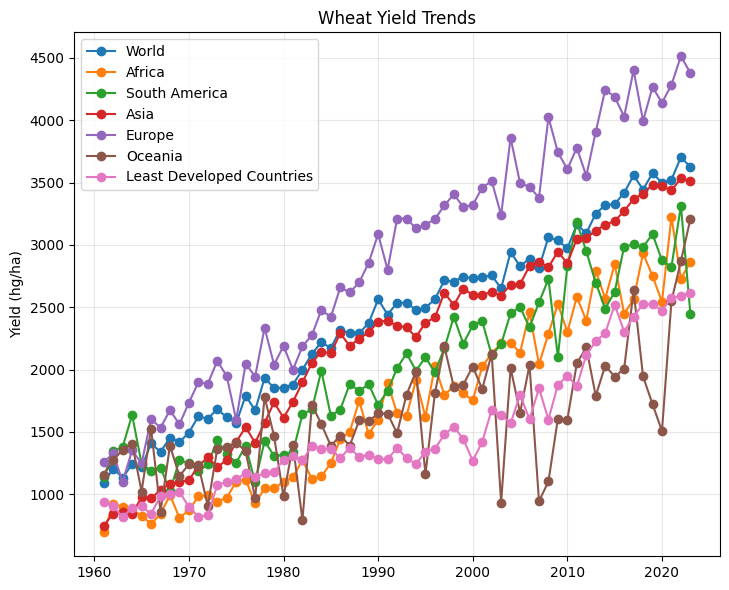

In [31]:
corr_matrix = df_transposed.corr()

plt.figure(figsize=(14, 6))

# Line Plot
plt.subplot(1, 2, 1)
for country in df_transposed.columns:
    plt.plot(df_transposed.index, df_transposed[country], marker='o', label=country)
plt.title('Wheat Yield Trends')
plt.ylabel('Yield (hg/ha)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()